## Check Collinearity of Features (Best-Performing B-Point ML Model)

### Setup and Helper Functions

#### Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from fau_colors import cmaps, register_fausans_font
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

%load_ext autoreload
%autoreload 2

In [3]:
register_fausans_font()
plt.close("all")

palette = sns.color_palette(cmaps.faculties_light)
sns.set_theme(context="notebook", style="ticks", font="sans-serif", palette=palette)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "FAUSans Office"

#### Datapaths

In [4]:
data_path = Path("../../results")
rater = "rater_01"

### Load Features of the Best-Performing Experiment

The current best-performing B-point ML model (cf. `regression/B_Point_Regression.ipynb`) is trained on the reduced, NaN-including feature set `rr_interval_ms_estimated`, `debski1993-second-derivative`, `drost2022`, and `lozano2007-linear-regression` (`..._include_nan_three_best_only.csv`). NaN values are kept as-is (not imputed/dropped) since the RandomForestRegressor pipeline is able to handle missing values natively.

In [5]:
input_data_b_point = pd.read_csv(
    data_path.joinpath(f"rr-interval/{rater}/train_data_b_point_rr_interval_include_nan.csv"),
    index_col=[0, 1, 2, 3, 4, 5],
).astype(float)

feature_cols = input_data_b_point.columns.tolist()
print(f"Features: {feature_cols}")
input_data_b_point.head()

Features: ['rr_interval_ms_estimated', 'arbol2017-isoelectric-crossings', 'arbol2017-second-derivative', 'arbol2017-third-derivative', 'debski1993-second-derivative', 'drost2022', 'forouzanfar2018', 'lozano2007-linear-regression', 'lozano2007-quadratic-regression', 'miljkovic2022', 'pale2021', 'sherwood1990', 'stern1985']


,,,,,,rr_interval_ms_estimated,arbol2017-isoelectric-crossings,arbol2017-second-derivative,arbol2017-third-derivative,debski1993-second-derivative,drost2022,forouzanfar2018,lozano2007-linear-regression,lozano2007-quadratic-regression,miljkovic2022,pale2021,sherwood1990,stern1985
,participant,condition,phase,heartbeat_id_reference,b_point_sample_reference,,,,,,,,,,,,,
0,GDN0005,Dummy,HoldingBreath,0,388.0,850.0,438.0,398.0,394.0,452.0,400.0,550.0,412.0,384.0,442.0,388.0,442.0,388.0
1,GDN0005,Dummy,HoldingBreath,1,404.0,778.0,340.0,350.0,244.0,388.0,420.0,402.0,404.0,384.0,288.0,246.0,330.0,402.0
2,GDN0005,Dummy,HoldingBreath,3,376.0,746.0,382.0,296.0,386.0,366.0,386.0,388.0,366.0,348.0,386.0,374.0,382.0,374.0
3,GDN0005,Dummy,HoldingBreath,4,390.0,766.0,394.0,344.0,396.0,376.0,396.0,398.0,372.0,348.0,398.0,388.0,394.0,388.0
4,GDN0005,Dummy,HoldingBreath,5,386.0,790.0,398.0,312.0,388.0,418.0,392.0,390.0,378.0,354.0,392.0,384.0,400.0,384.0


In [6]:
print(f"Shape: {input_data_b_point.shape}")
print("\nMissing values per feature:")
print(input_data_b_point.isna().sum())
print("\nRows with at least one NaN:", input_data_b_point.isna().any(axis=1).sum())
print("Complete-case rows:", input_data_b_point.dropna().shape[0])

Shape: (11239, 13)

Missing values per feature:
rr_interval_ms_estimated           101
arbol2017-isoelectric-crossings     15
arbol2017-second-derivative          0
arbol2017-third-derivative           2
debski1993-second-derivative       424
drost2022                            0
forouzanfar2018                    164
lozano2007-linear-regression         0
lozano2007-quadratic-regression      0
miljkovic2022                        0
pale2021                             0
sherwood1990                       343
stern1985                           24
dtype: int64

Rows with at least one NaN: 934
Complete-case rows: 10305


### Pairwise Correlation (NaN-Robust)

`DataFrame.corr()` computes correlations pairwise, using all available (non-NaN) observations for each pair, so no rows need to be dropped.

In [7]:
corr_pearson = input_data_b_point.corr(method="pearson")
corr_spearman = input_data_b_point.corr(method="spearman")
corr_pearson

,rr_interval_ms_estimated,arbol2017-isoelectric-crossings,arbol2017-second-derivative,arbol2017-third-derivative,debski1993-second-derivative,drost2022,forouzanfar2018,lozano2007-linear-regression,lozano2007-quadratic-regression,miljkovic2022,pale2021,sherwood1990,stern1985
rr_interval_ms_estimated,1.000000,0.879063,0.914505,0.750871,0.900900,0.911410,0.871030,0.942681,0.925860,0.862865,0.384524,0.894388,0.849133
arbol2017-isoelectric-crossings,0.879063,1.000000,0.942264,0.814234,0.898246,0.940682,0.916145,0.947691,0.934741,0.945639,0.484122,0.993694,0.896146
arbol2017-second-derivative,0.914505,0.942264,1.000000,0.806415,0.958299,0.970604,0.921506,0.982251,0.967720,0.930886,0.408215,0.945020,0.906771
arbol2017-third-derivative,0.750871,0.814234,0.806415,1.000000,0.767536,0.828901,0.800386,0.812029,0.813009,0.814959,0.462110,0.808856,0.780496
debski1993-second-derivative,0.900900,0.898246,0.958299,0.767536,1.000000,0.957103,0.915044,0.963987,0.941915,0.902861,0.361648,0.903326,0.903024
drost2022,0.911410,0.940682,0.970604,0.828901,0.957103,1.000000,0.942707,0.982857,0.968855,0.936231,0.451693,0.944863,0.925834
forouzanfar2018,0.871030,0.916145,0.921506,0.800386,0.915044,0.942707,1.000000,0.936041,0.909899,0.917985,0.488088,0.923214,0.970516
lozano2007-linear-regression,0.942681,0.947691,0.982251,0.812029,0.963987,0.982857,0.936041,1.000000,0.983776,0.937914,0.417540,0.953919,0.920370
lozano2007-quadratic-regression,0.925860,0.934741,0.967720,0.813009,0.941915,0.968855,0.909899,0.983776,1.000000,0.924829,0.412557,0.942816,0.894578
miljkovic2022,0.862865,0.945639,0.930886,0.814959,0.902861,0.936231,0.917985,0.937914,0.924829,1.000000,0.480119,0.953458,0.902733


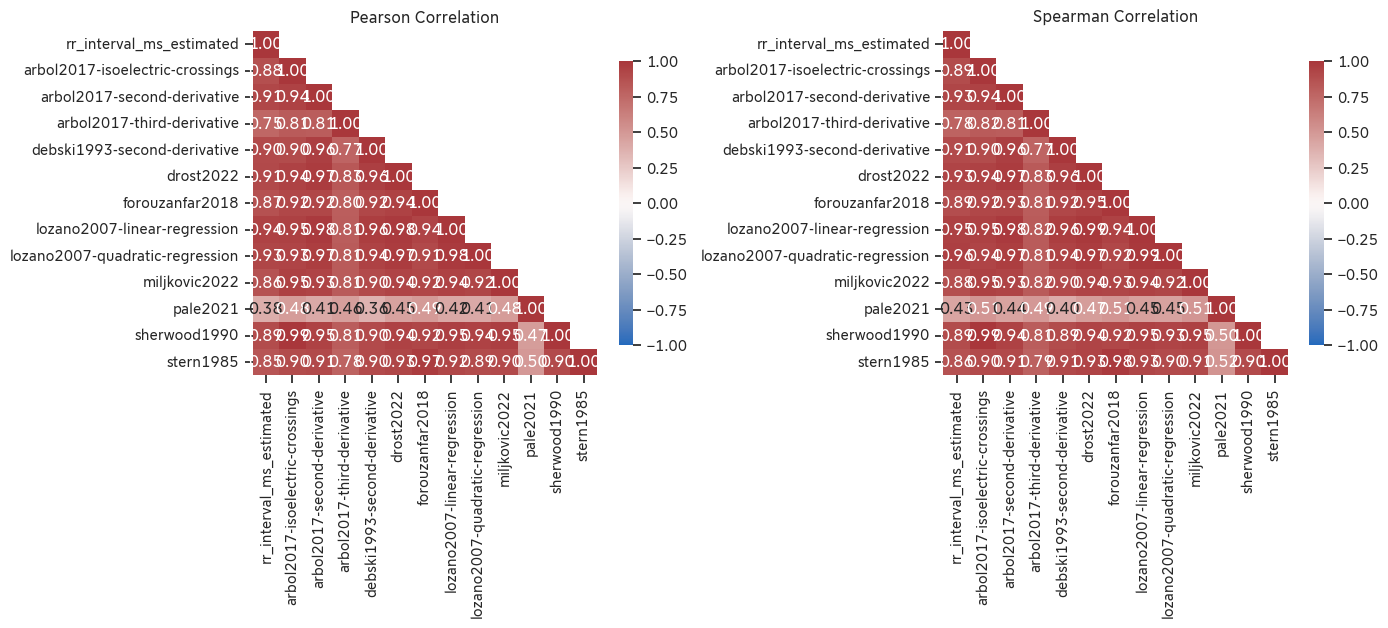

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for ax, corr, title in zip(axs, [corr_pearson, corr_spearman], ["Pearson", "Spearman"], strict=False):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title(f"{title} Correlation")

fig.tight_layout()

### Variance Inflation Factor (VIF)

VIF requires a complete design matrix, so it is computed on the complete-case subset of the NaN-including data (rows where all four features are present). This still reflects the feature set actually used by the model; only the correlation heatmap above uses every available (non-NaN) observation.

In [9]:
complete_case_data = input_data_b_point.dropna()
print(f"Complete-case rows used for VIF: {complete_case_data.shape[0]} / {input_data_b_point.shape[0]}")

# variance_inflation_factor expects a design matrix that includes an intercept/constant
# column; without it, VIFs are computed relative to the origin and are strongly inflated.
X_vif = add_constant(complete_case_data[feature_cols])
vif_data = pd.DataFrame(
    {
        "feature": feature_cols,
        "VIF": [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(col)) for col in feature_cols],
    }
).sort_values("VIF", ascending=False)
vif_data

Complete-case rows used for VIF: 10305 / 11239


,feature,VIF
7,lozano2007-linear-regression,378.527716
8,lozano2007-quadratic-regression,124.406716
1,arbol2017-isoelectric-crossings,84.223223
11,sherwood1990,80.217464
5,drost2022,49.146429
2,arbol2017-second-derivative,36.385544
6,forouzanfar2018,25.971272
12,stern1985,20.154260
4,debski1993-second-derivative,19.243815
9,miljkovic2022,14.986067


As a rule of thumb, VIF > 5 (or > 10, depending on the source) indicates problematic multicollinearity.

In [10]:
high_vif = vif_data[vif_data["VIF"] > 5]
if high_vif.empty:
    print("No features with VIF > 5 — no strong multicollinearity detected.")
else:
    print("Features with VIF > 5 (potential multicollinearity):")
    print(high_vif)

Features with VIF > 5 (potential multicollinearity):
                            feature         VIF
7      lozano2007-linear-regression  378.527716
8   lozano2007-quadratic-regression  124.406716
1   arbol2017-isoelectric-crossings   84.223223
11                     sherwood1990   80.217464
5                         drost2022   49.146429
2       arbol2017-second-derivative   36.385544
6                   forouzanfar2018   25.971272
12                        stern1985   20.154260
4      debski1993-second-derivative   19.243815
9                     miljkovic2022   14.986067
0          rr_interval_ms_estimated   11.692018
